# Video Segments

This notebook explores the distribution of video segments for the labels: NaturalImages, GaussianDot, Gabor, PinkNoise, and RandomDots.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from utils.dataset import DataSet

Define the paths used to access data and metadata.

In [2]:
# data folder
folder_data = repo_root / 'data'

# metadata folder
folder_meta = repo_root / 'metadata'

# mice/recording folders
all_recording_folders = [
    'dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29234-6-9-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29712-5-9-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29515-10-12-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29623-4-9-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20',
]

Initialize a `DataSet` object to handle the full dataset.

In [3]:
# Inizialize and object from DataSet to handle the dataset
ds = DataSet(folder_data, folder_metadata=folder_meta, recording=all_recording_folders, check=False)

# load trials metadata
trials_df = ds.get_trials_metadata()

# load segment metadata
segments_df = ds.get_segments_metadata()

# Mapping from recording name to rec-animalID-session-scan format
mapping = {}
for rec in ds.recording:
    x = rec.split("-")
    mapping[rec] = f"rec-{ds.info[rec]['animal_id']}-{ds.info[rec]['session']}-{ds.info[rec]['scan_idx']}"


Initializing DataSet -------------------------------------------------------------------------------

Data integrity check skipped -----------------------------------------------------------------------
 > If you want to check it, set check and check_data to True when initializing the DataSet.
 > Data is assumed to be valid. Misbehavior may occur if the data is corrupted.

Metadata integrity check skipped -------------------------------------------------------------------
 > If you want to check it, set check and check_metadata to True when initializing the DataSet.
 > Metadata will be assumed to be valid for existing folders and invalid for missing folders.

Loading neurons metadata ---------------------------------------------------------------------------
 > Loading neurons for recording dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce from metadata
 > Loading neurons for recording dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce from metadata
 > Loading neurons fo

## Number of different segments

Count the number of different segment per label. 

`Backgound` refers to segments classify as homogenous frames (single colour)

96 different segments for label RandomDots
216 different segments for label PinkNoise
1 different segments for label Background
180 different segments for label NaturalImages
72 different segments for label Gabor
210 different segments for label GaussianDot


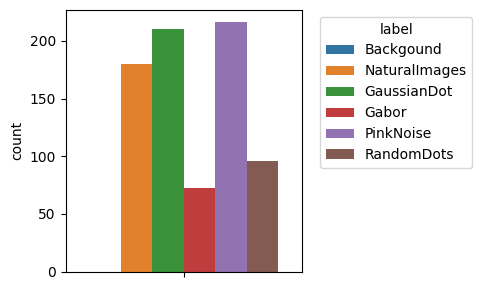

In [4]:
# count the total number of different segment per label
ordered_labels = ["Backgound", 'NaturalImages','GaussianDot','Gabor','PinkNoise','RandomDots']

labels = set(ds.segments_df['segment_label'].to_list())
fig, ax =plt.subplots(nrows=1, ncols=1, figsize=(5, 3))
count_segments = pd.DataFrame(columns=['label', 'count'])
for i, lab in enumerate(labels):
    df_segments_lab = ds.filter_segments(segment_label=lab)
    count = df_segments_lab["segment_ID"].nunique()
    count_segments.loc[len(count_segments)] = [lab, count]
    print(f"{count} different segments for label {lab}")
ax = sns.barplot(data=count_segments, y="count", hue="label", hue_order=ordered_labels)
ax.legend(
    title="label",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
fig.tight_layout()
fig.savefig(Path(repo_root, 'figures', f"count-segments-labels.png"), dpi=300)


## Segment occurrence per recording

For each recording, count how many times each segment appears and plot a histogram showing the count distribution.

In [5]:
counts = ds.count_segments_across(["segment_ID","recording","segment_label"])
results = counts.value_counts(["count", "recording", "segment_label"]).reset_index(name="n_segments")
results

,count,recording,segment_label,n_segments
0,10,dynamic29712-5-9-Video-9b4f6a1a067fe51e15306b9...,GaussianDot,210
1,10,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,GaussianDot,210
2,10,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,GaussianDot,175
3,10,dynamic29514-2-9-Video-8744edeac3b4d1ce16b6809...,GaussianDot,140
4,10,dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b...,GaussianDot,140
5,10,dynamic29515-10-12-Video-9b4f6a1a067fe51e15306...,GaussianDot,140
6,10,dynamic29712-5-9-Video-9b4f6a1a067fe51e15306b9...,Gabor,72
7,10,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,PinkNoise,72
8,10,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,PinkNoise,72
9,10,dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b...,PinkNoise,72



Recording: rec-29156-11-10 ============================================

Label: GaussianDot
- 175 segments, 10 times
- 35 segments, 9 times
Total segments: 210

Label: PinkNoise
- 60 segments, 10 times
- 12 segments, 9 times
Total segments: 72

Label: RandomDots
- 28 segments, 10 times
- 4 segments, 9 times
Total segments: 32

Recording: rec-29228-2-10 ============================================

Label: NaturalImages
- 50 segments, 10 times
- 10 segments, 9 times
Total segments: 60

Label: Gabor
- 60 segments, 10 times
- 12 segments, 9 times
Total segments: 72

Label: PinkNoise
- 60 segments, 10 times
- 12 segments, 9 times
Total segments: 72

Recording: rec-29234-6-9 ============================================

Label: NaturalImages
- 60 segments, 10 times
Total segments: 60

Label: Gabor
- 60 segments, 10 times
- 12 segments, 9 times
Total segments: 72

Label: RandomDots
- 32 segments, 10 times
Total segments: 32

Recording: rec-29513-3-5 ===========================================

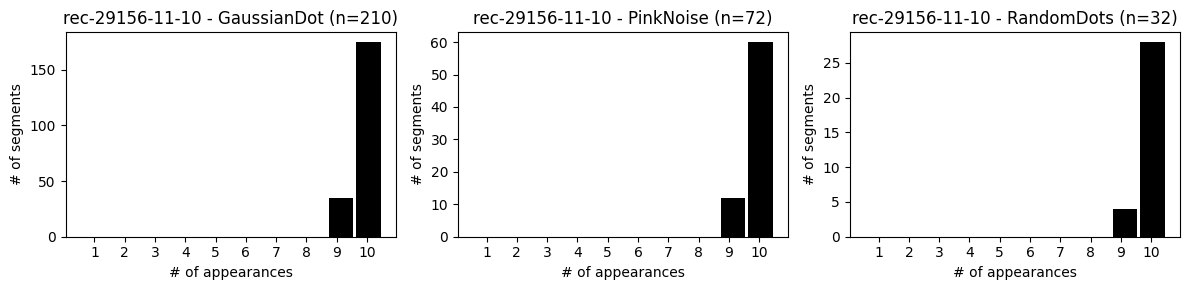

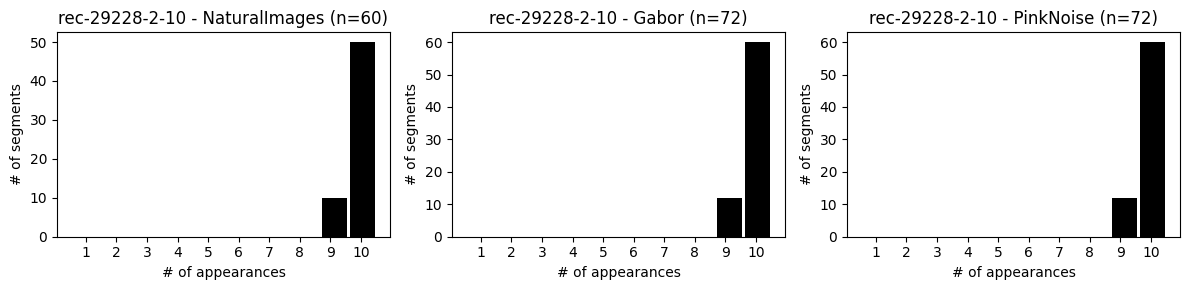

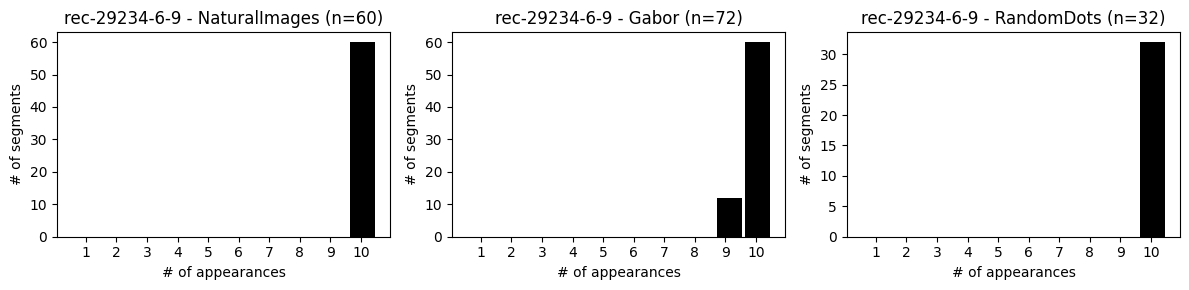

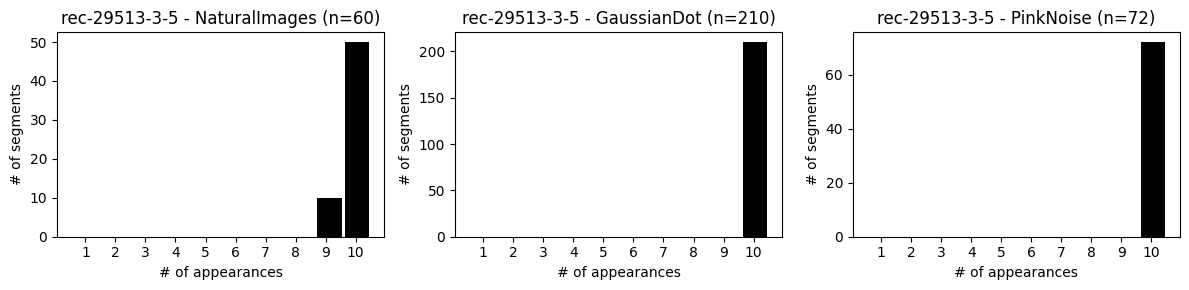

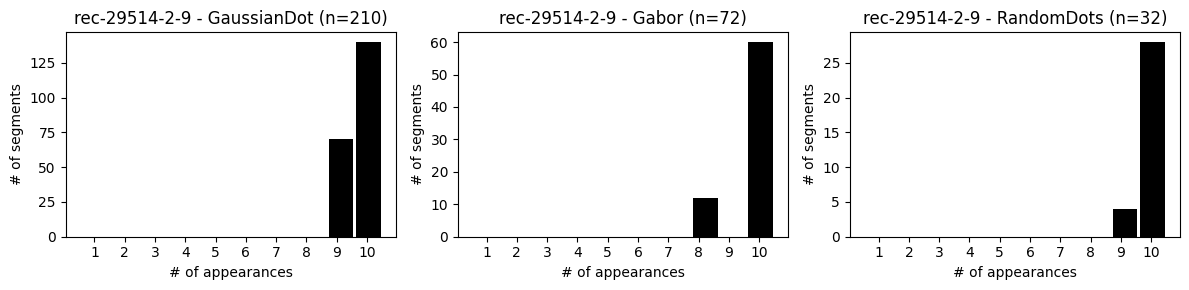

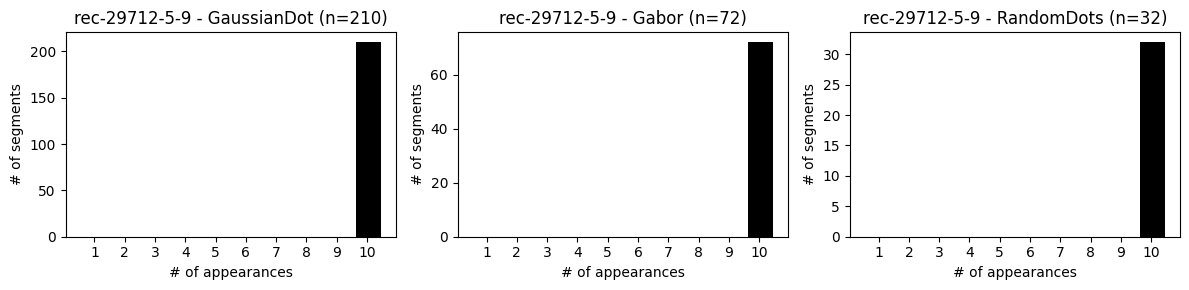

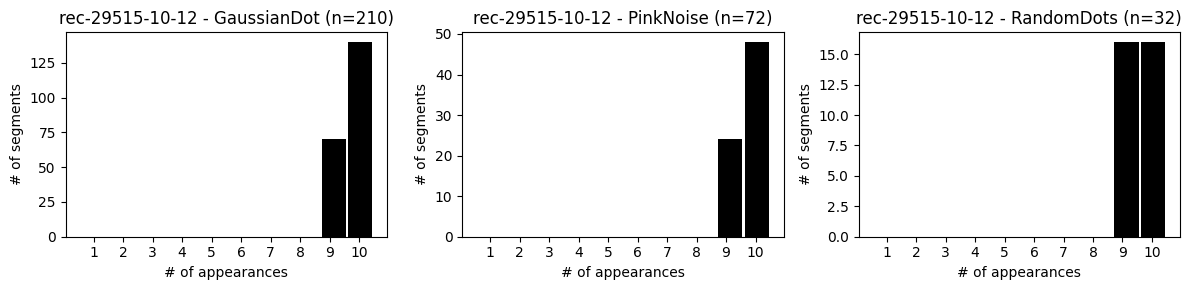

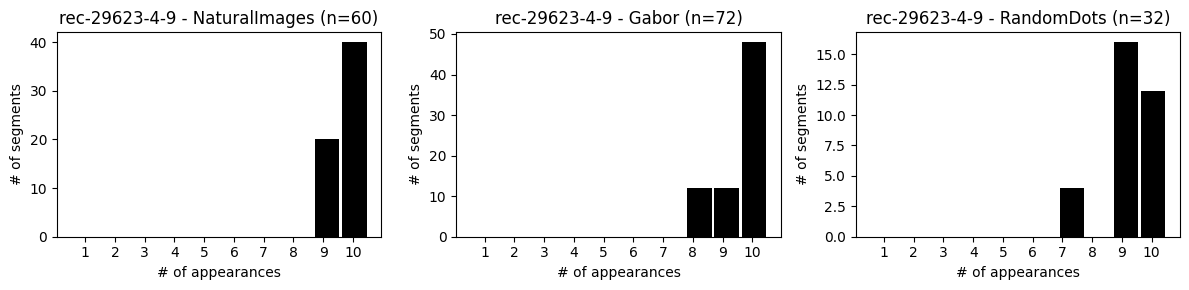

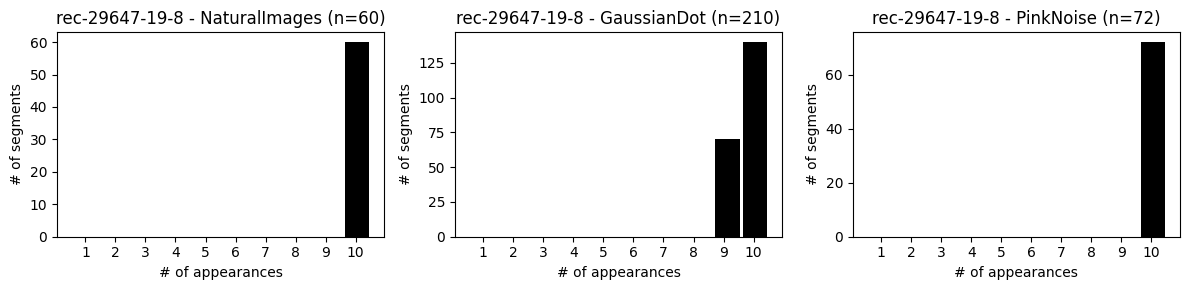

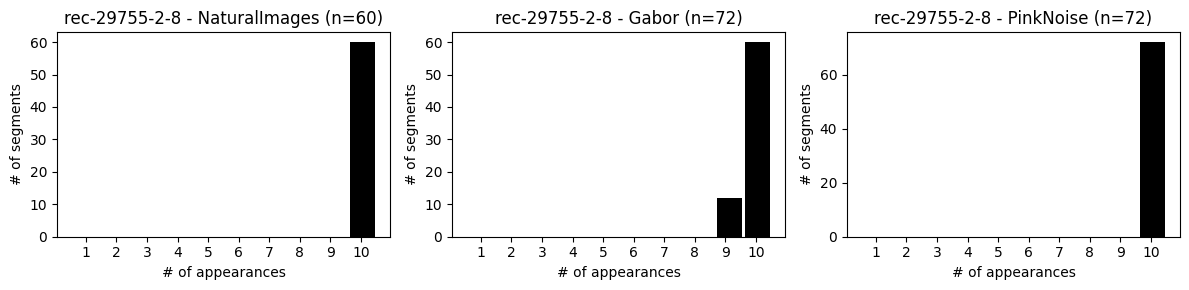

In [6]:
# count the number of occurences of each segment per recording
counts = ds.count_segments_across(["segment_ID","recording","segment_label"])
results = counts.value_counts(["count", "recording", "segment_label"]).reset_index(name="n_segments")

ordered_labels = ["Backgound", 'NaturalImages','GaussianDot','Gabor','PinkNoise','RandomDots']

for rec in ds.recording:
    all_segments_df_rec = ds.filter_segments(recording=rec)
    labels = set(all_segments_df_rec['segment_label'].to_list())
    labels.discard("Background")
    labels = [x for x in ordered_labels if x in labels]
    print(f"\nRecording: {mapping[rec]} ============================================")

    fig, ax =plt.subplots(nrows=1, ncols=3, figsize=(12, 3))
    for i, label in enumerate(labels):
        counts_rec_lab = counts[(counts['recording']==rec) & (counts['segment_label']==label)]
        results_rec_lab = results[(results['recording']==rec) & (results['segment_label']==label)]
        print(f"\nLabel: {label}")
        for iter, row in results_rec_lab.iterrows():
            print(f"- {row['n_segments']} segments, {row['count']} times")
        print(f"Total segments: {len(counts_rec_lab)}")

        d = counts_rec_lab['count'].to_numpy()
        xmax = np.max(d)
        h = ax[i].hist(d, range=(.5, xmax+0.5), bins=xmax+1, color='k',rwidth=0.9)
        ax[i].set_xticks(np.arange(1,xmax+1))
        ax[i].set_title(f"{mapping[rec]} - {label} (n={len(d)})")
        ax[i].set_xlabel("# of appearances")
        ax[i].set_ylabel("# of segments")
    fig.tight_layout()
    fig.savefig(Path(repo_root, 'figures', f"count-segments-labels_{mapping[rec]}.png"), dpi=300)

## Segment occurrence across recordings

Count, for each segment ID, in how many recordings it appears.
Then plot a histogram of the recording counts.

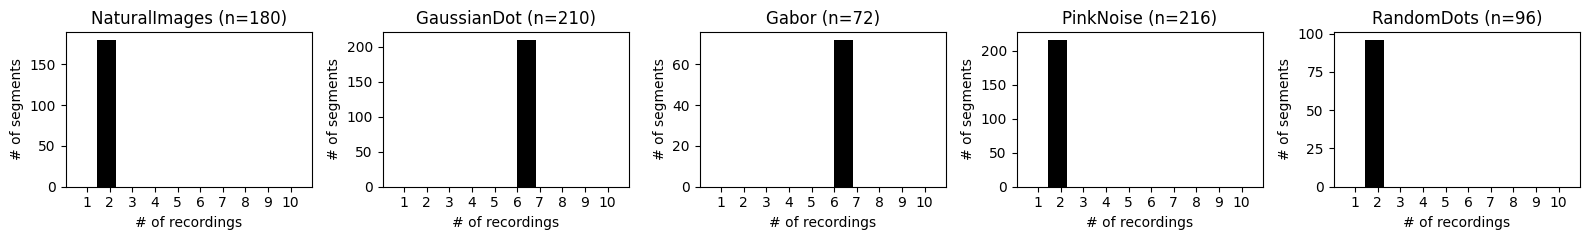

In [7]:
labels = ['NaturalImages','GaussianDot','Gabor','PinkNoise','RandomDots']

fig, ax =plt.subplots(nrows=1, ncols=len(labels), figsize=(16, 2.5))
xmax = 10
for i, lab in enumerate(labels):
    df_segments_lab = ds.filter_segments(segment_label=lab)
    count_recordings = df_segments_lab.groupby("segment_ID")["recording"].nunique()
    count_recordings = count_recordings.reset_index()
    count_recordings.columns = ["segment_ID"]+["n_recordings"]
    d = count_recordings["n_recordings"].to_numpy()
    h = ax[i].hist(d, range=(.5, xmax+0.5), bins=xmax+1, color='k',rwidth=0.9)
    ax[i].set_xticks(np.arange(1,xmax+1))
    ax[i].set_title(f"{lab} (n={len(d)})")
    ax[i].set_xlabel("# of recordings")
    ax[i].set_ylabel("# of segments")
plt.tight_layout()
fig.savefig(Path(repo_root, 'figures', f"count-recordings-x-segment_x-label.png"), dpi=300)


# Check Segment similarity

In [8]:
def plot_dissimilarity_matrix(dissimilarity):
    fig, ax =plt.subplots(nrows=1, ncols=1, figsize=(6, 6))
    vmax = np.max(dissimilarity[np.isnan(dissimilarity)==False].flatten())
    im_diss = ax.imshow(dissimilarity, cmap='Reds_r', vmin=0, vmax=vmax, aspect='equal')
    ax.set_aspect('equal', adjustable='box')
    bcol = fig.colorbar(im_diss, ax=ax)
    bcol.set_label("dissimilarity", rotation=270, labelpad=15)
    ax.set_xlabel("video index")
    ax.set_ylabel("video index")
    return fig, ax

def plot_dissimilarity_hist(dissimilarity,bins=100, range=None):
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 6))
    if range is None:
        range = (0, np.max(dissimilarity[np.isnan(dissimilarity)==False].flatten()))
    h = ax.hist(dissimilarity.flatten(), range=range, bins=bins, color='k', rwidth=1)
    ax.set_xlabel("dissimilarity")
    ax.set_ylabel("video counts")
    return fig, ax

## Gabor

In [26]:
thelabel = 'Gabor'
dissimilarity, all_segments = ds.compute_dissimilarity_segments(thelabel)

- 18 distinct videos found
- 216 segments were found and loaded
Computing dissimilarity between segments...


Computing dissimilarity: 100%|██████████| 216/216 [00:44<00:00,  4.88it/s]


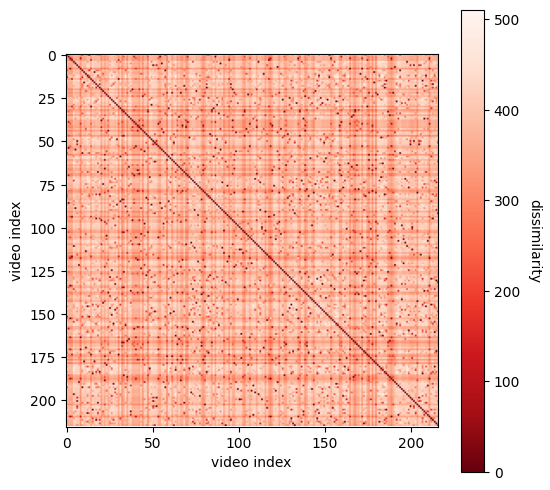

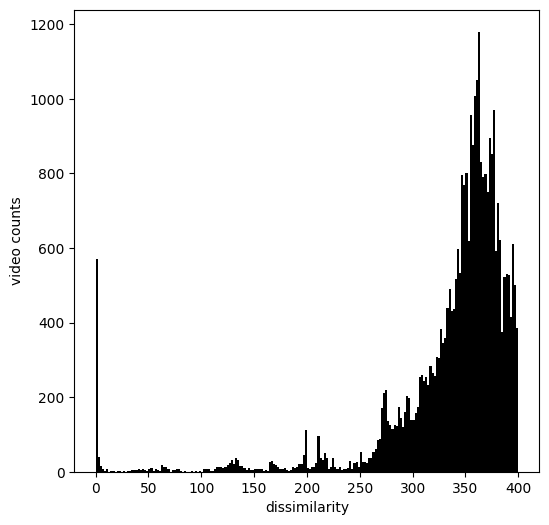

In [29]:
# plot dissimilarity matrix
fig, ax = plot_dissimilarity_matrix(dissimilarity)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-matrix_{thelabel}_segments.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=200, range=(0, 400))
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_segments.png"), dpi=300)

In [33]:
mask = (dissimilarity < 30) & (dissimilarity > 10)
# find the pairs of segments that are similar according to the mask
similar_pairs = np.argwhere(mask)


similar pair of segments: 24 and 44 is 11.09579069071125


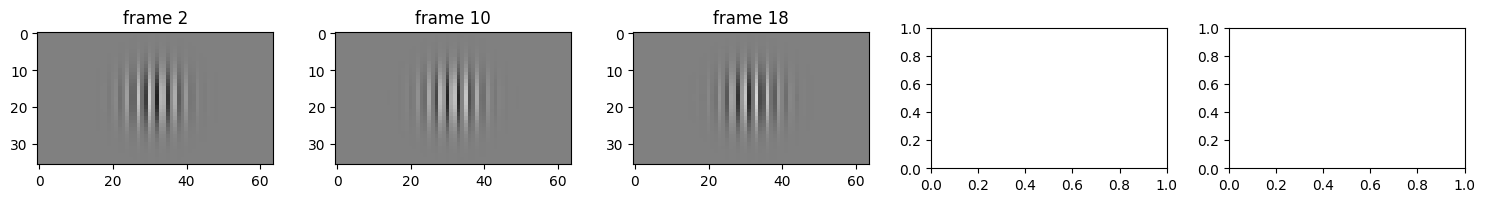

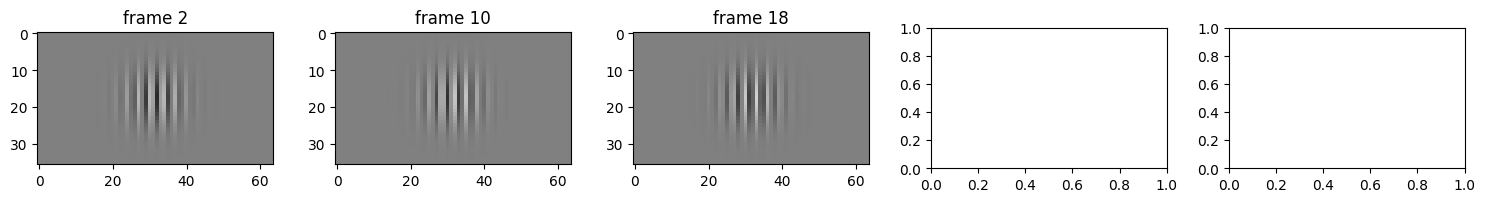

In [40]:
i=0
print(f"similar pair of segments: {similar_pairs[i,0]} and {similar_pairs[i,1]} is {dissimilarity[similar_pairs[i,0], similar_pairs[i,1]]}")
segment_a = all_segments[similar_pairs[i,0]]
segment_b = all_segments[similar_pairs[i,1]]
_ = segment_a.plot_frames(segment_a.pick_key_frames())
_ = segment_b.plot_frames(segment_b.pick_key_frames())

## Gaussian Dot

In [41]:
thelabel = 'GaussianDot'
dissimilarity, all_segments = ds.compute_dissimilarity_segments(thelabel)

- 18 distinct videos found
- 630 segments were found and loaded
Computing dissimilarity between segments...


Computing dissimilarity: 100%|██████████| 630/630 [00:50<00:00, 12.38it/s]


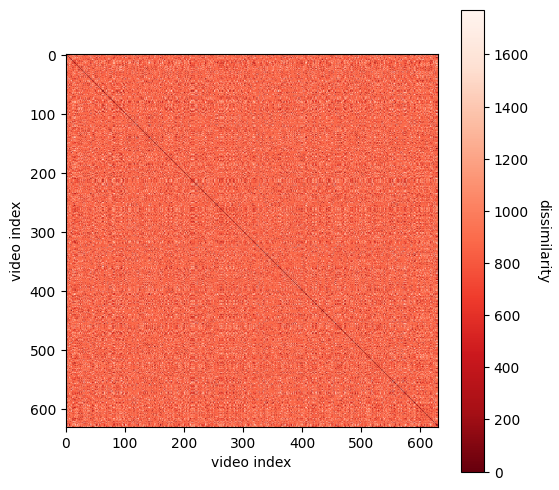

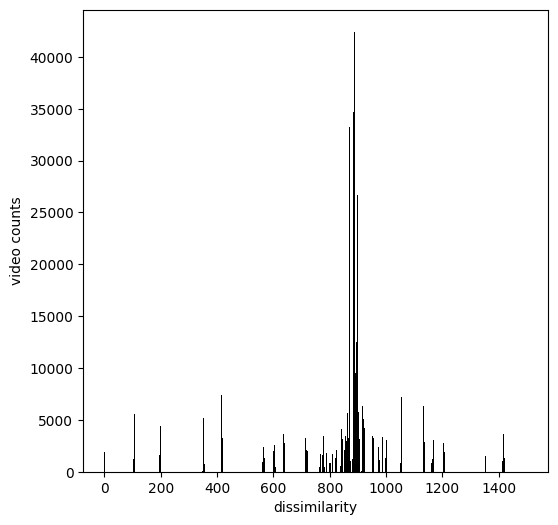

In [44]:
# plot dissimilarity matrix
fig, ax = plot_dissimilarity_matrix(dissimilarity)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-matrix_{thelabel}_segments.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=500, range=(0, 1500))
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_segments.png"), dpi=300)

## RandomDots

In [45]:
thelabel = 'RandomDots'
dissimilarity, all_segments = ds.compute_dissimilarity_segments(thelabel)

- 24 distinct videos found
- 96 segments were found and loaded
Computing dissimilarity between segments...


Computing dissimilarity: 100%|██████████| 96/96 [00:18<00:00,  5.14it/s]


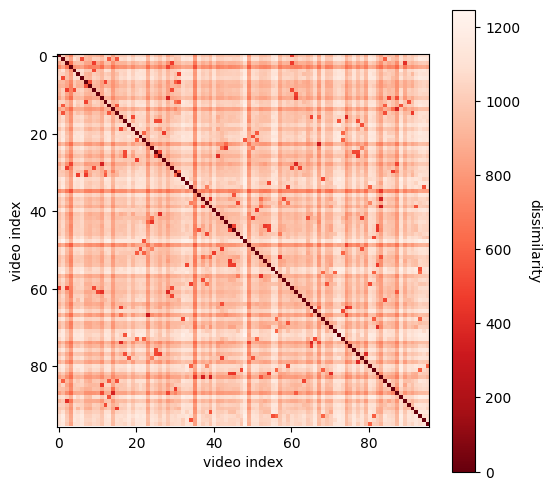

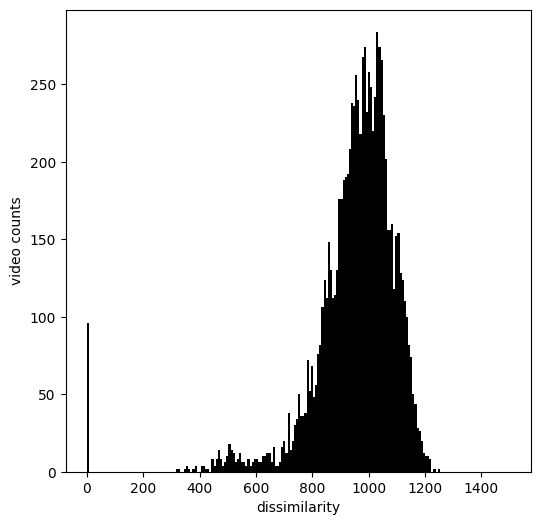

In [46]:
# plot dissimilarity matrix
fig, ax = plot_dissimilarity_matrix(dissimilarity)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-matrix_{thelabel}_segments.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=200, range=(0, 1500))
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_segments.png"), dpi=300)

## PinkNoise

In [47]:
thelabel = 'PinkNoise'
dissimilarity, all_segments = ds.compute_dissimilarity_segments(thelabel)

- 18 distinct videos found
- 216 segments were found and loaded
Computing dissimilarity between segments...


Computing dissimilarity: 100%|██████████| 216/216 [00:44<00:00,  4.84it/s]


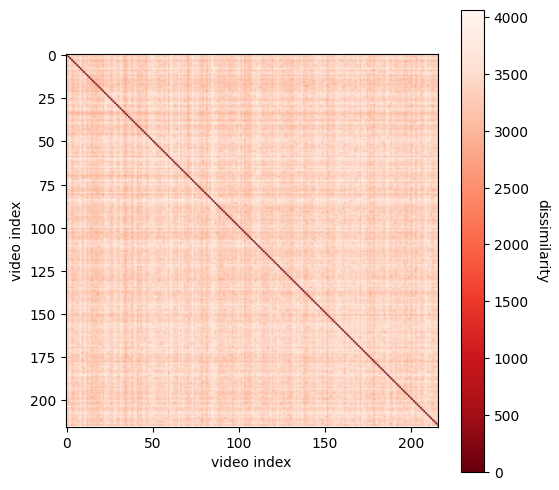

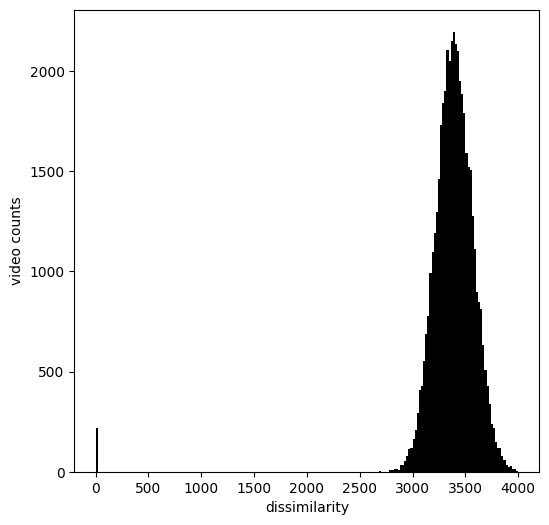

In [49]:
# plot dissimilarity matrix
fig, ax = plot_dissimilarity_matrix(dissimilarity)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-matrix_{thelabel}_segments.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=200, range=(0, 4000))
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_segments.png"), dpi=300)

## Natural Images

In [50]:
thelabel = 'NaturalImages'
dissimilarity, all_segments = ds.compute_dissimilarity_segments(thelabel)

- 20 distinct videos found
- 400 segments were found and loaded
Computing dissimilarity between segments...


Computing dissimilarity: 100%|██████████| 400/400 [00:28<00:00, 13.94it/s]


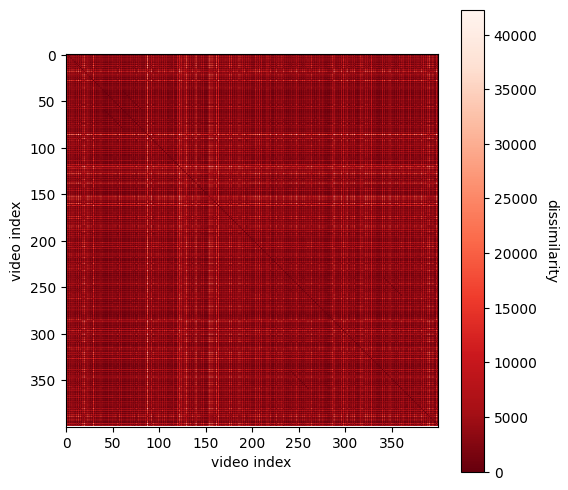

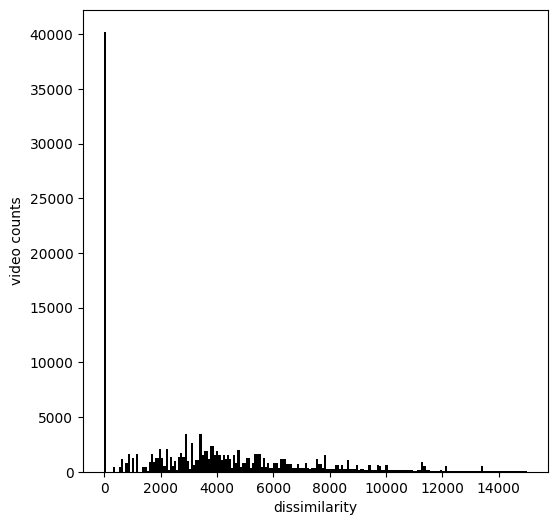

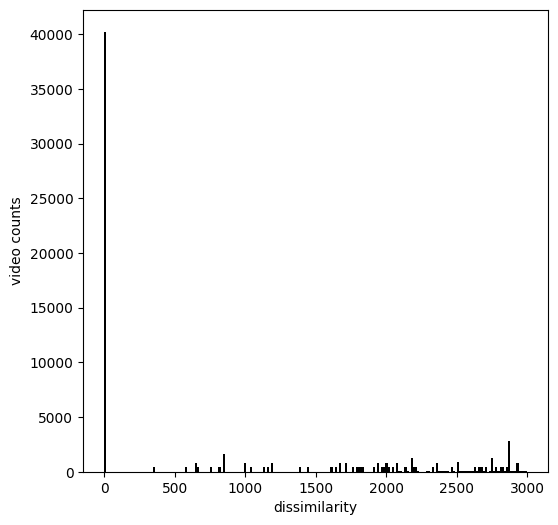

In [56]:
# plot dissimilarity matrix
fig, ax = plot_dissimilarity_matrix(dissimilarity)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-matrix_{thelabel}_segments.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=200, range=(0, 15000))
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_segments.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=200, range=(0, 3000))
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_segments_zoom.png"), dpi=300)